# Template attack on a float32 weight (template-based DPA)

This notebook follows the *Template-based DPA* section of
[Section 4.3.2 and 4.3.3 DPA on PRESENT](https://github.com/XIAOLUHOU/SCA-measurements-and-analysis----Experimental-results-for-textbook/blob/main/Section%204.3.2%20and%204.3.3%20DPA%20on%20PRESENT.ipynb),
with the PRESENT S-box output replaced by the product `weight * input` of the network.

| PRESENT notebook | this notebook |
|---|---|
| key nibble `k` (16 hypotheses) | weight `w` (thousands of candidate values) |
| plaintext nibble `pt` (known, random) | network input `x` (known, random) |
| intermediate value `S[k ^ pt]` | product `w * x` (float32) |
| leakage model: identity or Hamming weight | Hamming weight of the **top bits** of the product |
| profiling set `random_dataset`: random keys, **known** | profiling traces: random weights, **known** |
| attack set `random_pt_dataset`: fixed unknown key | attack blocks: one fixed weight per block, **unknown** |
| success rate / guessing entropy vs number of traces | success rate vs number of traces |

**The idea in one paragraph.** During profiling the weight is known, so for every trace the product `w*x` and therefore
its leakage class is known. For every class we measure what the power trace looks like at a few points of interest
(POIs): a mean vector and a covariance matrix, i.e. a Gaussian *template*. During the attack the weight is unknown.
For each candidate weight we compute which class every attack trace *would* belong to if the candidate were right, and
score the traces with the templates of those classes. The candidate whose classes explain the traces best is the weight.

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from decimal import Decimal
import chipwhisperer as cw

/home/piskotka/.local/lib/python3.14/site-packages/chipwhisperer/capture/trace/TraceWhisperer.py:31: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources # type: ignore


### Leakage model: Hamming weight of the top bits

The PRESENT key has 16 possible values, so the template classes could be the full 4-bit S-box output.
A float32 weight is continuous: no candidate on a finite grid reproduces the product **bit for bit**, because a
tiny error in `w` scrambles the low mantissa bits of `w*x`. The **top** bits (sign, 8 exponent bits and the first
`k` mantissa bits) only change when `w` is far off. So the class of a trace is

`class = HW( top (9 + k) bits of float32(w * x) )`,  classes `0 ... 9+k`.

The unknown lower bits are not ignored, they are absorbed by the template: the covariance of a class already contains
the noise they cause. `k` is a knob:
- small `k`: robust to grid error, but different weights (e.g. `w` and `w/16`) look similar;
- large `k`: sharp, but demands a very fine candidate grid.

That is why the attack has two stages (coarse then fine) with **two sets of templates**, one per `k`.

In [2]:
def hwu(u):
    """Hamming weight of uint32 values (any shape)."""
    b = np.ascontiguousarray(u, dtype=np.uint32).view(np.uint8).reshape(-1, 4)
    return np.unpackbits(b, axis=1).sum(1).reshape(np.shape(u))

def top_mask(k):
    keep = 9 + k
    return np.uint32((0xFFFFFFFF << (32 - keep)) & 0xFFFFFFFF)

def leak_class(product, k):
    """Leakage class of float32 products: HW of sign + exponent + top k mantissa bits."""
    return hwu(np.ascontiguousarray(product, dtype=np.float32).view(np.uint32) & top_mask(k)).astype(np.int64)

### Load the traces

`weights` is what was sent to the target for every trace. It is used in two ways only:
1. as the **known label** for the profiling traces (like `keys.txt` of the profiling dataset);
2. as the **ground truth** to check the attack result.

Traces that belong to one fixed weight are consecutive (the weight changes every `TRACES_PER_WEIGHT` traces during
capture), so a block is a run of equal weights.

In [3]:
WINDOW = (0, 1000)          # only the start of the capture contains the network computation

proj = cw.open_project("../data/raw/cw_project")
n = len(proj.waves)
traces = np.array(proj.waves[:n], dtype=np.float32)[:, WINDOW[0]:WINDOW[1]].astype(np.float64)
ti = np.array(proj.textins[:n], dtype=np.float64)              # (N, 2): (input, weight)
inputs = ti[:, 0].astype(np.float32)
weights = ti[:, 1].astype(np.float32)

change = np.flatnonzero(np.diff(weights) != 0) + 1
bounds = np.r_[0, change, n]
blocks = [np.arange(s, e) for s, e in zip(bounds[:-1], bounds[1:])]
print(f"{n} traces in {len(blocks)} blocks of {sorted(set(len(b) for b in blocks))} traces")

20000 traces in 40 blocks of [500] traces


### Profiling set and attack set

Like the two datasets in the PRESENT notebook:
- **profiling blocks**: weights known, used only to build the templates;
- **attack blocks**: each one is an independent attack on one fixed weight that is treated as unknown.

In [4]:
rng = np.random.default_rng(0)
order = rng.permutation(len(blocks))
n_prof = int(round(0.8 * len(blocks)))
prof_blocks = [blocks[i] for i in order[:n_prof]]
attack_blocks = [blocks[i] for i in order[n_prof:]]

prof_idx = np.concatenate(prof_blocks)
p_traces, p_inputs, p_weights = traces[prof_idx], inputs[prof_idx], weights[prof_idx]
print(f"{len(prof_blocks)} profiling blocks ({len(prof_idx)} traces), {len(attack_blocks)} attack blocks")

32 profiling blocks (16000 traces), 8 attack blocks


### Points of interest (POIs)

As in the PRESENT notebook the POIs are the samples that correlate most with the leakage (here: the Hamming weight of
the whole float32 product, known for the profiling traces). A minimum distance between POIs avoids picking three
neighbouring samples of the same peak.

In [5]:
K_COARSE, K_FINE = 8, 14
N_POIS, POI_MIN_DIST = 3, 8

labels = leak_class(p_inputs * p_weights, 23).astype(float)          # k = 23: all 32 bits of the product
t = p_traces - p_traces.mean(axis=0)
l = labels - labels.mean()
corr = (t * l[:, None]).sum(axis=0) / np.sqrt((t ** 2).sum(axis=0) * (l ** 2).sum())

POIS = []
for s in np.argsort(-np.abs(corr)):
    if all(abs(s - q) >= POI_MIN_DIST for q in POIS):
        POIS.append(int(s))
    if len(POIS) == N_POIS:
        break
POIS = sorted(POIS)
print("POIs:", POIS, " correlation with HW(product):", [f"{corr[s]:+.2f}" for s in POIS])

POIs: [573, 622, 657]  correlation with HW(product): ['-0.90', '-0.86', '-0.90']


### Step 1 — Build the templates (`build_template` in the PRESENT notebook)

For every class `c` collect the leakage at the POIs of all profiling traces whose product falls in class `c` and
compute the mean vector `mu_c` (one number per POI). Together with a covariance matrix `Sigma` this defines a
multivariate Gaussian `N(mu_c, Sigma)`: "what the POIs look like when the product is in class `c`".

Two differences to the PRESENT notebook, both because there are many more classes here (up to 24 instead of 5):

- **Pooled covariance.** The reference has one covariance matrix per class (`np.cov(..., bias=True)`). Classes in the
  tails have only a handful of profiling traces, which makes their covariance unreliable, so one covariance
  matrix is estimated from the within-class scatter of *all* classes (a *pooled template*).
- **Extrapolated means for rare classes.** A class with fewer than `MIN_COUNT` profiling traces gets its mean from a
  straight line fitted through the means of the well-populated classes (the leakage is roughly linear in the Hamming
  weight). A hypothesis that needs a class that never occurs is then not "impossible" but simply very unlikely,
  because its mean is far from what the trace shows. This also handles candidates like `w = 0` (product 0, class 0).

`INDEPENDENT_POIS = True` reproduces the reference's *independence* variant: the covariance is replaced by its
diagonal, i.e. POIs are assumed to be independent.

In [6]:
INDEPENDENT_POIS = False
MIN_COUNT = 30

def build_template(k):
    n_cls = 9 + k + 1
    cls = leak_class(p_inputs * p_weights, k)
    leak = p_traces[:, POIS]
    P = len(POIS)

    count = np.bincount(cls, minlength=n_cls)
    valid = count >= MIN_COUNT
    mean = np.zeros((n_cls, P))
    scatter = np.zeros((P, P))
    for c in np.flatnonzero(valid):
        d = leak[cls == c]
        mean[c] = d.mean(axis=0)
        scatter += (d - mean[c]).T @ (d - mean[c])
    cov = scatter / count[valid].sum()                                   # pooled covariance
    if INDEPENDENT_POIS:
        cov = np.diag(np.diag(cov))

    # rare classes: mean from a line through the well-populated classes
    cv = np.flatnonzero(valid)
    for p in range(P):
        slope, icpt = np.polyfit(cv, mean[cv, p], 1, w=np.sqrt(count[cv]))
        mean[~valid, p] = icpt + slope * np.flatnonzero(~valid)

    return dict(k=k, mean=mean, inv_cov=np.linalg.inv(cov), cov=cov, valid=valid, count=count)

tpl_coarse, tpl_fine = build_template(K_COARSE), build_template(K_FINE)
for name, tp in (('coarse', tpl_coarse), ('fine', tpl_fine)):
    print(f"{name} templates (k={tp['k']}): {tp['valid'].sum()} of {len(tp['valid'])} classes measured, the others extrapolated")

coarse templates (k=8): 9 of 18 classes measured, the others extrapolated
fine templates (k=14): 12 of 24 classes measured, the others extrapolated


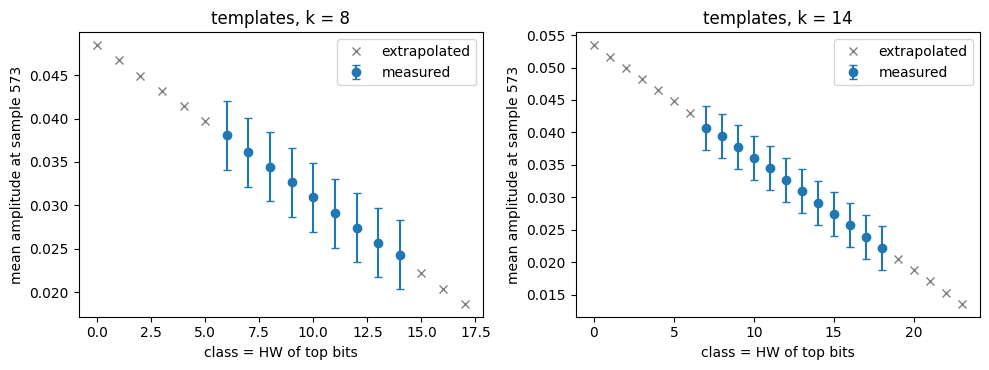

In [7]:
# The templates: mean amplitude at the first POI for every class (error bars: standard deviation)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, tp in zip(axes, (tpl_coarse, tpl_fine)):
    cl = np.arange(len(tp['valid']))
    sd = np.sqrt(tp['cov'][0, 0])
    ax.errorbar(cl[tp['valid']], tp['mean'][tp['valid'], 0], yerr=sd, fmt='o', capsize=3, label='measured')
    ax.plot(cl[~tp['valid']], tp['mean'][~tp['valid'], 0], 'x', color='gray', label='extrapolated')
    ax.set_xlabel('class = HW of top bits')
    ax.set_ylabel(f'mean amplitude at sample {POIS[0]}')
    ax.set_title(f"templates, k = {tp['k']}")
    ax.legend()
fig.tight_layout()
plt.show()

### Step 2 — Score the candidate weights (`template_prob_score` in the PRESENT notebook)

For a candidate weight `w` and attack trace `j` (input `x_j`, leakage `t_j` at the POIs):

1. hypothetical class `c = HW(top bits of w * x_j)`;
2. log-likelihood of the trace under the template of that class

   `ll(j, w) = -1/2 * (t_j - mu_c)^T  Sigma^-1  (t_j - mu_c)`

   (the reference also has `ln |Sigma_c|`; with one pooled covariance it is the same for all classes and drops out);
3. score of the candidate: `sum_j ll(j, w)` (the traces are independent given their class, so log-likelihoods add).

The candidate with the highest score is the recovered weight. In the reference the loop is over 16 keys; here it is
over all candidate weights, vectorised in chunks.

In [8]:
CHUNK = 1000          # candidates per batch (memory)

def per_trace_loglik(cands, x, leak, tpl):
    """Log-likelihood of every attack trace under every candidate weight -> array (candidates, traces).
    cands: float32 candidate weights, x: known inputs, leak: trace amplitudes at the POIs, shape (traces, POIs)."""
    out = np.empty((len(cands), len(x)))
    for i in range(0, len(cands), CHUNK):
        prod = (cands[i:i + CHUNK, None] * x[None, :]).astype(np.float32)
        c = leak_class(prod, tpl['k'])                                   # hypothetical class of each trace
        d = leak[None, :, :] - tpl['mean'][c]                             # (cands, traces, POIs)
        out[i:i + CHUNK] = -0.5 * np.einsum('cnp,pq,cnq->cn', d, tpl['inv_cov'], d)
    return out

### Step 3 — Recover a weight: coarse, then fine

1. **Coarse**: score every candidate of a grid over [-1, 1] with the coarse templates (`K_COARSE`) and keep the best
   few *distinct* peaks (finalists).
2. **Fine**: around every finalist score a much finer local grid with the fine templates (`K_FINE`). The finalists are
   compared with each other at the same fine resolution, and the best one is the recovered weight.

The coarse templates are robust to the grid error but cannot separate look-alikes such as `w` and `w/16`; the fine
templates can, but only near the right value. Together they do both.

In [9]:
COARSE_STEP = Decimal('0.0001')
FINE_STEP, FINE_HALF_WIDTH = 1e-6, 1e-4
N_FINALISTS, FINALIST_SEP = 6, 0.005

grid = np.float32([float(Decimal('-1.0') + COARSE_STEP * i) for i in range(int(Decimal('2.0') / COARSE_STEP) + 1)])
n_fine = int(round(FINE_HALF_WIDTH / FINE_STEP))
fine_offsets = np.arange(-n_fine, n_fine + 1) * FINE_STEP

def recover_weight(x, leak):
    """Recover the weight from known inputs x and the trace amplitudes at the POIs. Returns the weight and
    the refined finalists as (weight, score) pairs."""
    coarse = per_trace_loglik(grid, x, leak, tpl_coarse).sum(axis=1)
    fin = []
    for i in np.argsort(coarse)[::-1]:
        if all(abs(grid[i] - grid[j]) > FINALIST_SEP for j in fin):
            fin.append(i)
        if len(fin) == N_FINALISTS:
            break
    refined = []
    for i in fin:
        fine_c = float(grid[i]) + fine_offsets
        s = per_trace_loglik(fine_c.astype(np.float32), x, leak, tpl_fine).sum(axis=1)
        j = int(np.argmax(s))
        refined.append((fine_c[j], s[j]))
    best = max(refined, key=lambda r: r[1])[0]
    return best, refined

### Score against the number of traces (one attack block)

Like the "Probability scores" plot of the PRESENT notebook: the accumulated score of every hypothesis while the
attack traces are added one by one. The **blue** line is the true weight (only known here for the evaluation), the grey
lines are the other finalists of the search. A correct attack shows blue rising above all grey lines.

true weight +0.9122281, recovered +0.9122300


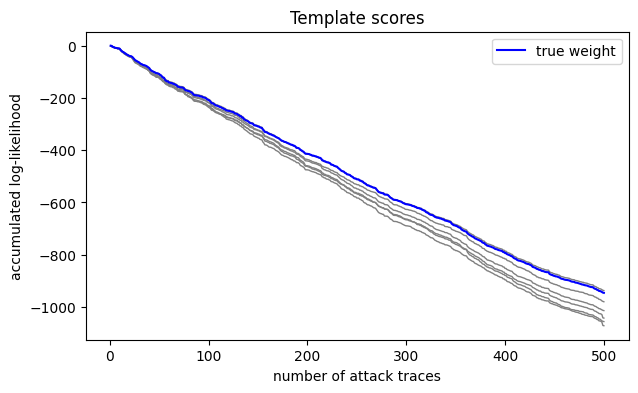

In [10]:
blk = attack_blocks[0]
x, leak, true_w = inputs[blk], traces[blk][:, POIS], float(weights[blk[0]])
best, refined = recover_weight(x, leak)
print(f"true weight {true_w:+.7f}, recovered {best:+.7f}")

hyp = np.float32([r[0] for r in refined] + [true_w])                 # finalists + the true weight
ll = per_trace_loglik(hyp, x, leak, tpl_fine)
cum = np.cumsum(ll, axis=1)

plt.figure(figsize=(7, 4))
for i in range(len(hyp) - 1):
    plt.plot(np.arange(1, len(x) + 1), cum[i], color='#808080', lw=1)
plt.plot(np.arange(1, len(x) + 1), cum[-1], color='b', lw=1.5, label='true weight')
plt.xlabel('number of attack traces')
plt.ylabel('accumulated log-likelihood')
plt.title('Template scores')
plt.legend()
plt.show()

### Attack all attack blocks

Every attack block is an independent attack: recover the weight from its traces, then compare with the ground truth.
A weight counts as recovered when it is within `TOL` of the true value.

In [11]:
TOL = 5e-6
results = []
for blk in attack_blocks:
    rec, _ = recover_weight(inputs[blk], traces[blk][:, POIS])
    true_w = float(weights[blk[0]])
    results.append((true_w, rec))
    print(f"true {true_w:+.7f}  recovered {rec:+.7f}  error {abs(rec - true_w):.1e}  {'OK' if abs(rec - true_w) <= TOL else 'MISS'}")

ok = np.array([abs(r - t) <= TOL for t, r in results])
print(f"\n{ok.mean():.0%} of the {len(ok)} attack blocks recovered")

true +0.9122281  recovered +0.9122300  error 1.9e-06  OK
true +0.9356247  recovered +0.9356260  error 1.3e-06  OK
true -0.9415327  recovered -0.9415330  error 3.5e-07  OK
true +0.9201797  recovered +0.9201800  error 3.1e-07  OK
true +0.5040922  recovered +0.5040920  error 1.9e-07  OK
true +0.2955496  recovered +0.2955500  error 4.0e-07  OK
true -0.6034369  recovered -0.6034370  error 1.2e-07  OK
true -0.4574938  recovered -0.4574940  error 2.6e-07  OK

100% of the 8 attack blocks recovered


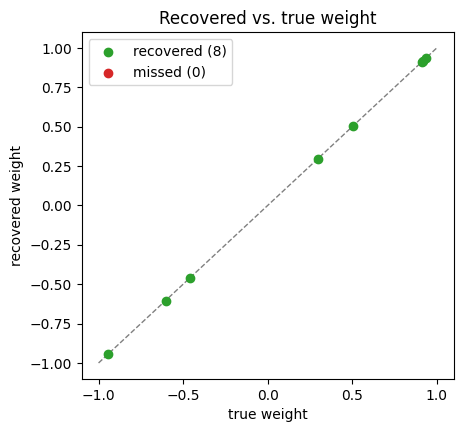

In [12]:
true_w = np.array([t for t, _ in results])
rec_w = np.array([r for _, r in results])

plt.figure(figsize=(4.8, 4.5))
plt.plot([-1, 1], [-1, 1], color='gray', ls='--', lw=1)
plt.scatter(true_w[ok], rec_w[ok], color='tab:green', label=f'recovered ({ok.sum()})', zorder=3)
plt.scatter(true_w[~ok], rec_w[~ok], color='tab:red', label=f'missed ({(~ok).sum()})', zorder=3)
plt.xlabel('true weight')
plt.ylabel('recovered weight')
plt.title('Recovered vs. true weight')
plt.legend()
plt.show()

### Success rate against the number of attack traces

Like `get_SR_GE` of the PRESENT notebook: repeat the attack with random subsets of `n` traces of a block and count
how often the weight is recovered.

   1 traces: success rate 0.00
   4 traces: success rate 0.00
   9 traces: success rate 0.00
  16 traces: success rate 0.00
  25 traces: success rate 0.06
  36 traces: success rate 0.00
  49 traces: success rate 0.17
  64 traces: success rate 0.11
  81 traces: success rate 0.44
 100 traces: success rate 0.22
 121 traces: success rate 0.44
 144 traces: success rate 0.39
 169 traces: success rate 0.61
 196 traces: success rate 0.56
 225 traces: success rate 0.56
 256 traces: success rate 0.67
 289 traces: success rate 0.61
 324 traces: success rate 0.61
 361 traces: success rate 0.78
 400 traces: success rate 0.83
 441 traces: success rate 0.83
 484 traces: success rate 0.89
 529 traces: success rate 1.00
 576 traces: success rate 1.00


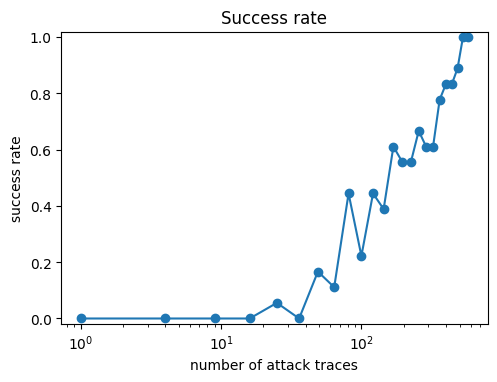

In [16]:
TRACE_COUNTS = [i**2 for i in range(1, 25)]
N_REPEATS = 3
SR_BLOCKS = attack_blocks[:6]

sr = []
for m in TRACE_COUNTS:
    hits = []
    for blk in SR_BLOCKS:
        true_w = float(weights[blk[0]])
        for _ in range(N_REPEATS):
            sub = rng.choice(blk, min(m, len(blk)), replace=False)
            rec, _ = recover_weight(inputs[sub], traces[sub][:, POIS])
            hits.append(abs(rec - true_w) <= TOL)
    sr.append(np.mean(hits))
    print(f"{m:4d} traces: success rate {sr[-1]:.2f}")

plt.figure(figsize=(5.5, 3.8))
plt.plot(TRACE_COUNTS, sr, 'o-')
plt.xscale('log')
plt.ylim(-0.02, 1.02)
plt.xlabel('number of attack traces')
plt.ylabel('success rate')
plt.title('Success rate')
plt.show()